# Credit Risk Assessment Experiment

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
print("=" * 55)
print("     CREDIT RISK ASSESSMENT EXPERIMENT")
print("=" * 55)

# Setup output directory
NOTE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(NOTE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(NOTE_DIR, "german_credit_data.csv")

if os.path.exists(CSV_PATH):
    # Load from local CSV
    print("\n📂 Loading from local CSV...")
    df = pd.read_csv(CSV_PATH, index_col=0)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df = df.rename(columns={"risk": "target"})
    df["target"] = df["target"].map({"good": 0, "bad": 1})

else:
    # Auto-load from UCI
    print("\n📥 Downloading German Credit Dataset from UCI...")
    url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    cols = ["checking_account", "duration", "credit_history", "purpose",
            "credit_amount", "savings_account", "employment", "installment_rate",
            "personal_status", "other_debtors", "residence_since", "property",
            "age", "other_installments", "housing", "existing_credits",
            "job", "num_dependents", "telephone", "foreign_worker", "target"]
    df = pd.read_csv(url, sep=" ", header=None, names=cols)
    df["target"] = df["target"].map({1: 0, 2: 1})   # 1=good→0, 2=bad→1

print(f"✅ Dataset loaded: {df.shape[0]} applicants, {df.shape[1]} columns")
print(f"\n   Creditworthy (Good) : {(df['target'] == 0).sum()}")
print(f"   High Risk    (Bad)  : {(df['target'] == 1).sum()}")
print(f"\n--- First 5 rows ---")
print(df.head())

     CREDIT RISK ASSESSMENT EXPERIMENT

📥 Downloading German Credit Dataset from UCI...
✅ Dataset loaded: 1000 applicants, 21 columns

   Creditworthy (Good) : 700
   High Risk    (Bad)  : 300

--- First 5 rows ---
  checking_account  duration credit_history purpose  credit_amount  \
0              A11         6            A34     A43           1169   
1              A12        48            A32     A43           5951   
2              A14        12            A34     A46           2096   
3              A11        42            A32     A42           7882   
4              A11        24            A33     A40           4870   

  savings_account employment  installment_rate personal_status other_debtors  \
0             A65        A75                 4             A93          A101   
1             A61        A73                 2             A92          A101   
2             A61        A74                 2             A93          A101   
3             A61        A74                

In [4]:
print("\n🔧 Preprocessing data...")

# Encode all categorical (object) columns to numbers
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
        df[col] = le.fit_transform(df[col].astype(str))

df.fillna(df.median(numeric_only=True), inplace=True)
print("✅ Encoding & missing value handling done.")


🔧 Preprocessing data...
✅ Encoding & missing value handling done.


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✂️  Train: {len(X_train)} | Test: {len(X_test)}")


✂️  Train: 800 | Test: 200


In [6]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print("\n" + "=" * 55)
print("             MODEL RESULTS")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": accuracy}
    print(f"\n🔹 {name}  —  Accuracy: {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred,
                                target_names=["Good Credit", "Bad Credit"],
                                zero_division=0))


             MODEL RESULTS

🔹 Logistic Regression  —  Accuracy: 76.50%
              precision    recall  f1-score   support

 Good Credit       0.81      0.86      0.84       140
  Bad Credit       0.63      0.53      0.58        60

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200


🔹 Decision Tree  —  Accuracy: 74.50%
              precision    recall  f1-score   support

 Good Credit       0.79      0.86      0.82       140
  Bad Credit       0.59      0.48      0.53        60

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.68       200
weighted avg       0.73      0.74      0.74       200


🔹 Random Forest  —  Accuracy: 76.50%
              precision    recall  f1-score   support

 Good Credit       0.79      0.91      0.84       140
  Bad Credit       0.68      0.42      0.52        60

    accuracy                      

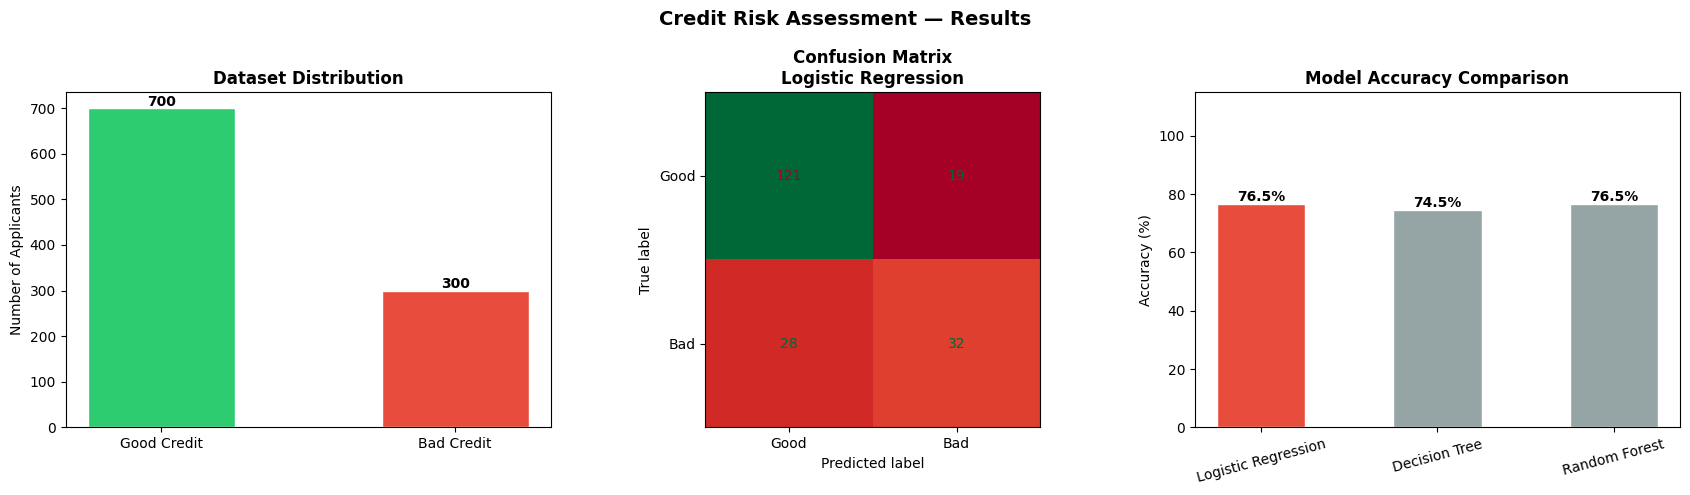

✅ Plot saved.


In [7]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
best_pred = results[best_name]["y_pred"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Credit Risk Assessment — Results", fontsize=14, fontweight="bold")

# Plot 1 — Class Distribution
ax = axes[0]
counts = y.value_counts().sort_index()
ax.bar(["Good Credit", "Bad Credit"], counts.values,
       color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
ax.set_title("Dataset Distribution", fontweight="bold")
ax.set_ylabel("Number of Applicants")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

# Plot 2 — Confusion Matrix (best model)
ax = axes[1]
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["Good", "Bad"]).plot(
    ax=ax, colorbar=False, cmap="RdYlGn"
)
ax.set_title(f"Confusion Matrix\n{best_name}", fontweight="bold")

# Plot 3 — Accuracy Comparison
ax = axes[2]
names  = list(results.keys())
accs   = [results[m]["accuracy"] * 100 for m in names]
colors = ["#e74c3c" if m == best_name else "#95a5a6" for m in names]
bars   = ax.bar(names, accs, color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 115)
ax.set_title("Model Accuracy Comparison", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "credit_risk_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved.")

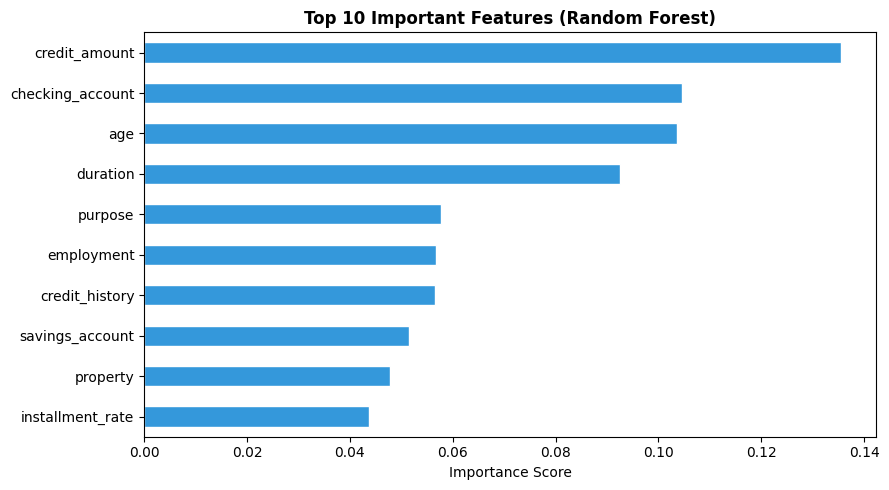

✅ Feature importance plot saved.


In [8]:
rf_model    = results["Random Forest"]["model"]
feat_names  = X.columns.tolist()
importances = pd.Series(rf_model.feature_importances_, index=feat_names)
top10       = importances.nlargest(10).sort_values()

plt.figure(figsize=(9, 5))
top10.plot(kind="barh", color="#3498db", edgecolor="white")
plt.title("Top 10 Important Features (Random Forest)", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "credit_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved.")

In [9]:
print("\n" + "=" * 55)
print("          LIVE CREDIT RISK PREDICTOR")
print("=" * 55)

best_model = results[best_name]["model"]

def predict_credit(applicant_data: dict):
    """
    Pass a dictionary with the same feature names as the dataset.
    Missing features will be filled with 0.
    """
    row = pd.DataFrame([applicant_data])
    # Fill any missing columns with 0
    for col in X.columns:
        if col not in row.columns:
            row[col] = 0
    row = row[X.columns]
    row_scaled = scaler.transform(row)
    pred = best_model.predict(row_scaled)[0]
    prob = best_model.predict_proba(row_scaled)[0] if hasattr(best_model, "predict_proba") else None
    label = "❌ HIGH RISK (Bad Credit)" if pred == 1 else "✅ LOW RISK  (Good Credit)"
    print(f"\n   Prediction : {label}")
    if prob is not None:
        print(f"   Confidence : {max(prob)*100:.1f}%")

# Example applicants
print("\n👤 Applicant 1 — Young, low income, large loan:")
predict_credit({"age": 22, "credit_amount": 15000, "duration": 48, "job": 1})

print("\n👤 Applicant 2 — Middle-aged, stable job, small loan:")
predict_credit({"age": 45, "credit_amount": 2000, "duration": 12, "job": 3})


          LIVE CREDIT RISK PREDICTOR

👤 Applicant 1 — Young, low income, large loan:

   Prediction : ❌ HIGH RISK (Bad Credit)
   Confidence : 95.3%

👤 Applicant 2 — Middle-aged, stable job, small loan:

   Prediction : ❌ HIGH RISK (Bad Credit)
   Confidence : 74.1%


In [10]:
print("\n" + "=" * 55)
print("             FINAL SUMMARY")
print("=" * 55)
for name in results:
    print(f"  {name:<22} → {results[name]['accuracy']*100:.2f}%")
print(f"\n🏆 Best Model : {best_name}")
print("✅ Experiment complete!")


             FINAL SUMMARY
  Logistic Regression    → 76.50%
  Decision Tree          → 74.50%
  Random Forest          → 76.50%

🏆 Best Model : Logistic Regression
✅ Experiment complete!
